Shape: (285, 5)
Date range: 1996-01-01 00:00:00 to 2019-09-01 00:00:00


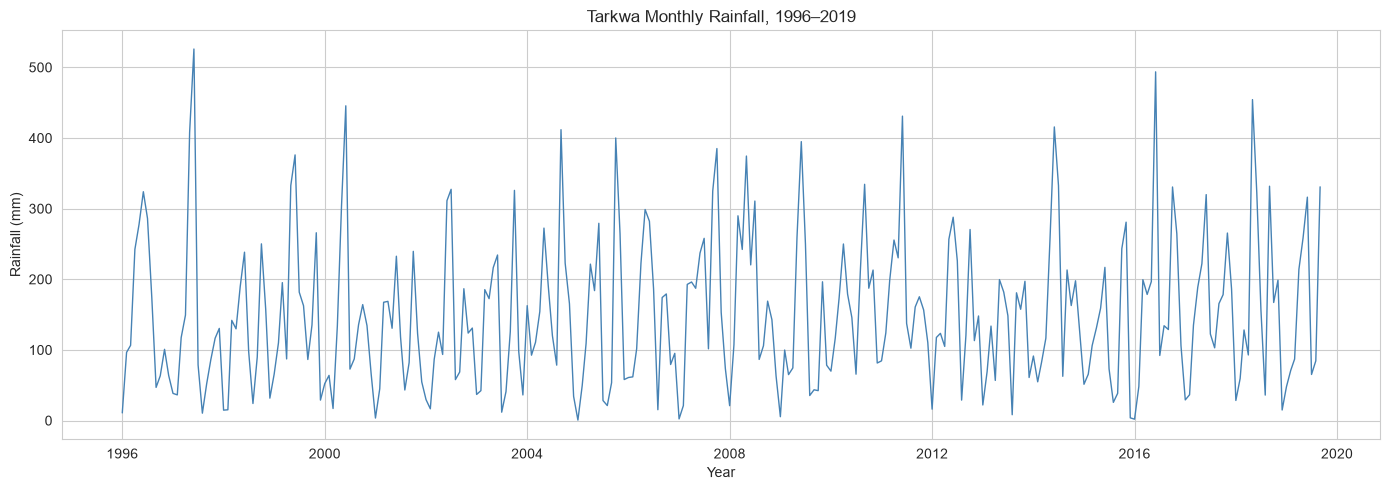

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv("../data/tarkwa_monthly_clean.csv", parse_dates=["Date"])

print("Shape:", df.shape)
print("Date range:", df["Date"].min(), "to", df["Date"].max())

plt.figure(figsize=(14, 5))
plt.plot(df["Date"], df["Monthly_Rainfall_mm"], color="steelblue", linewidth=1)
plt.title("Tarkwa Monthly Rainfall, 1996–2019")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.tight_layout()
plt.savefig("../models/eda_full_timeseries.png", dpi=150)
plt.show()

Average rainfall by month (mm):
Month_Name
January       39.4
February      67.5
March        135.6
April        162.8
May          247.6
June         309.3
July         156.1
August        72.3
September    158.6
October      205.3
November     174.2
December      77.5
Name: Monthly_Rainfall_mm, dtype: float64


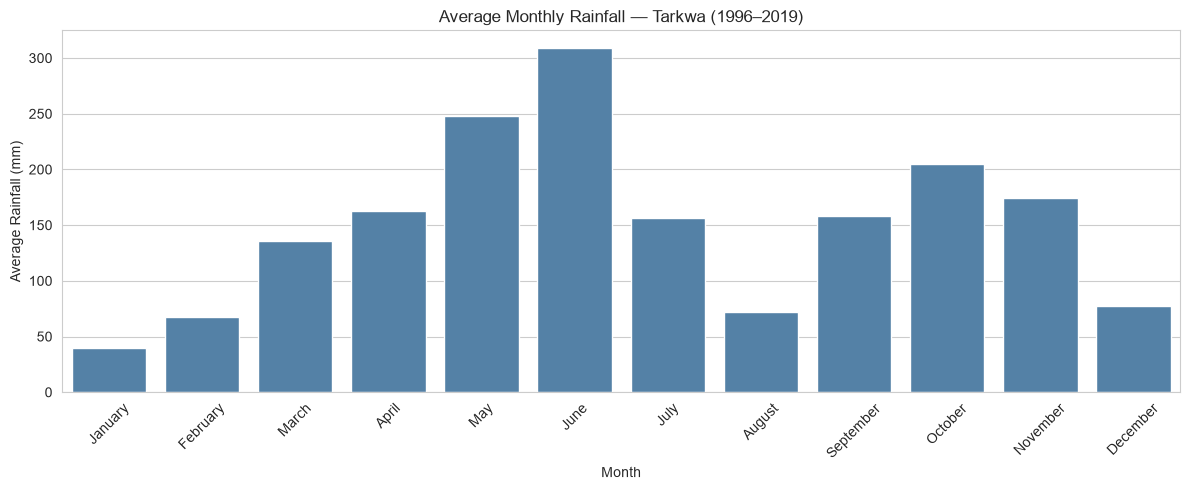

In [2]:
# Order months chronologically, not alphabetically, for the chart
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

monthly_avg = df.groupby("Month_Name")["Monthly_Rainfall_mm"].mean().reindex(month_order)

print("Average rainfall by month (mm):")
print(monthly_avg.round(1))

plt.figure(figsize=(12, 5))
sns.barplot(x=monthly_avg.index, y=monthly_avg.values, color="steelblue")
plt.title("Average Monthly Rainfall — Tarkwa (1996–2019)")
plt.xlabel("Month")
plt.ylabel("Average Rainfall (mm)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../models/eda_monthly_climatology.png", dpi=150)
plt.show()

In [3]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["Monthly_Rainfall_mm"])

print("ADF Statistic:", round(result[0], 4))
print("p-value:", round(result[1], 4))
print("Critical values:")
for key, value in result[4].items():
    print(f"   {key}: {round(value, 4)}")

if result[1] <= 0.05:
    print("\n→ Result: Series IS stationary (reject H0 at 5% significance)")
else:
    print("\n→ Result: Series is NOT stationary (fail to reject H0) — differencing will likely be needed")

ADF Statistic: -3.8759
p-value: 0.0022
Critical values:
   1%: -3.4545
   5%: -2.8722
   10%: -2.5724

→ Result: Series IS stationary (reject H0 at 5% significance)


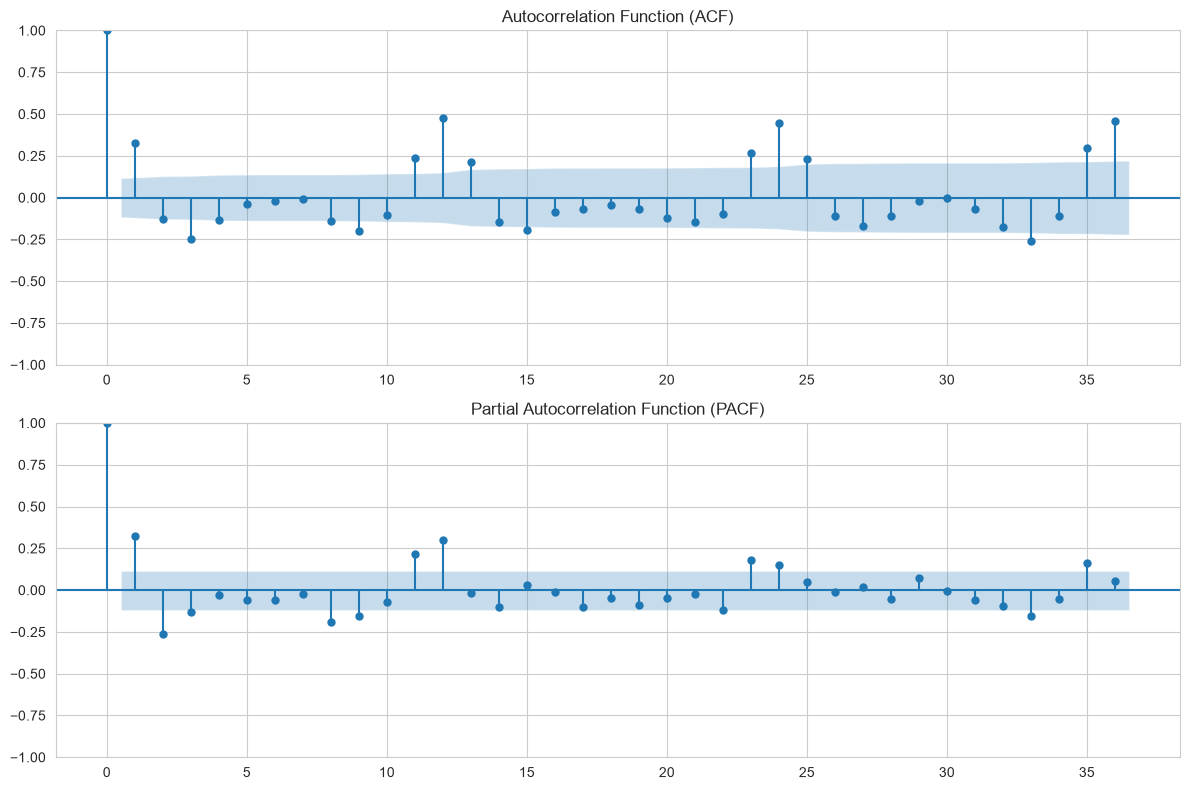

In [4]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(df["Monthly_Rainfall_mm"], lags=36, ax=axes[0])
axes[0].set_title("Autocorrelation Function (ACF)")

plot_pacf(df["Monthly_Rainfall_mm"], lags=36, ax=axes[1])
axes[1].set_title("Partial Autocorrelation Function (PACF)")

plt.tight_layout()
plt.savefig("../models/eda_acf_pacf.png", dpi=150)
plt.show()